# BLIP Product Image Captioning

Adapting a pretrained vision-language model (**Salesforce BLIP**) to generate short, e-commerce-style captions directly from product images - no fine-tuning, just smart prompting and post-processing.

**Stack:** Hugging Face Transformers · PyTorch · PIL · BLIP (`Salesforce/blip-image-captioning-base`)

**Pipeline**
1. Load a public product-image dataset from the Hugging Face Hub
2. Load pretrained BLIP and run plain zero-shot captioning
3. Steer captions toward an e-commerce style using prompt conditioning
4. Clean up captions with a lightweight post-processing layer
5. Visualize results against real product listing titles
6. Try it on your own images
7. Export results and (optionally) push them to the Hugging Face Hub

>  **Runtime:** This will run on CPU, but a GPU makes it much faster — in Colab go to `Runtime → Change runtime type → T4 GPU`.

In [1]:
!pip install -q transformers accelerate datasets pillow matplotlib huggingface_hub evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.1 MB/s eta 0:00:00


In [2]:
import re
import io
import textwrap

import torch
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datasets import load_dataset, Dataset
from transformers import BlipProcessor, BlipForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## 1. Load a public product-image dataset

We'll use [`ashraq/fashion-product-images-small`](https://huggingface.co/datasets/ashraq/fashion-product-images-small) - about 44k real e-commerce product photos with metadata (category, color, season, and an actual listing title) sourced from a Kaggle fashion-retail catalog. The listing titles will come in handy later as a rough sanity check for our generated captions, even though we never train on them.

In [3]:
NUM_SAMPLES = 12

dataset = load_dataset("ashraq/fashion-product-images-small", split="train")
print(f"Total products in dataset: {len(dataset):,}")

sample = dataset.shuffle(seed=42).select(range(NUM_SAMPLES))
sample[0]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/867 [00:00<?, ?B/s]

data/train-00000-of-00002-6cff4c59f91661(…):   0%|          | 0.00/136M [00:00<?, ?B/s]

data/train-00001-of-00002-bb459e5ac5f01e(…):   0%|          | 0.00/135M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/44072 [00:00<?, ? examples/s]

Total products in dataset: 44,072


{'id': 47396,
 'gender': 'Women',
 'masterCategory': 'Accessories',
 'subCategory': 'Bags',
 'articleType': 'Handbags',
 'baseColour': 'Blue',
 'season': 'Summer',
 'year': 2012.0,
 'usage': 'Casual',
 'productDisplayName': 'Baggit Women Blue Bag',
 'image': <PIL.Image.Image image mode=RGB size=60x80>}

## 2. Load pretrained BLIP

`Salesforce/blip-image-captioning-base` is the smaller captioning checkpoint - a good speed/quality trade-off for Colab. Swap in `Salesforce/blip-image-captioning-large` for noticeably richer captions if you have GPU time to spare.

In [4]:
MODEL_ID = "Salesforce/blip-image-captioning-base"  # try "-large" for richer captions

processor = BlipProcessor.from_pretrained(MODEL_ID)
model = BlipForConditionalGeneration.from_pretrained(MODEL_ID).to(device)
model.eval()
print(f"Loaded {MODEL_ID} on {device}")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Loaded Salesforce/blip-image-captioning-base on cuda


## 3. Baseline: plain zero-shot captioning

First, let's see what BLIP produces with no steering at all, just "describe this image.

In [5]:
@torch.no_grad()
def caption_image(image, prompt=None, max_new_tokens=30):
    '''Generate a caption for a PIL image. If `prompt` is given, BLIP continues
    that text instead of starting from scratch (conditional captioning).'''
    image = image.convert("RGB")
    inputs = processor(image, text=prompt, return_tensors="pt").to(device)
    output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, num_beams=3)
    return processor.decode(output_ids[0], skip_special_tokens=True)

# Quick test on the first sample image
test_image = sample[0]["image"]
print("Listing title:  ", sample[0]["productDisplayName"])
print("BLIP (no prompt):", caption_image(test_image))

Listing title:   Baggit Women Blue Bag
BLIP (no prompt): a blue bag with a white background


## 4. Adapting BLIP for e-commerce style - without any training

This is the "adaptation" step. We're not changing any weights - instead we steer BLIP's generation with a **conditional text prompt** and optionally feed in the product's category to make the caption more specific. It's a cheap, fast way to nudge a general-purpose captioning model toward a narrower style.

Let's compare a few prompt strategies on the same image.

In [6]:
prompt_variants = {
    "unconditional": None,
    "product_photo": "a product photo of",
    "e-commerce listing": "an e-commerce listing photo of",
    "category-aware": f"a product photo of a {sample[0]['articleType'].lower()}",
}

for name, prompt in prompt_variants.items():
    caption = caption_image(test_image, prompt=prompt)
    print(f"{name:20s} -> {caption}")

unconditional        -> a blue bag with a white background
product_photo        -> a product photo of a blue handbag
e-commerce listing   -> an e - commerce listing photo of an e - commerce bag
category-aware       -> a product photo of a handbags bag


## 5. Post-processing: turning a caption into e-commerce copy

Raw BLIP output is grammatically a continuation of the prompt, so it needs light cleanup before it reads like real listing copy: trimming the prompt prefix, fixing capitalization and removing dangling fragments.

In [7]:
def to_ecommerce_caption(raw_caption, prompt):
    '''Light post-processing to turn BLIP's raw continuation into clean e-commerce copy.'''
    text = raw_caption.strip()

    # BLIP echoes the prompt at the start of the continuation -- strip it back off
    if prompt and text.lower().startswith(prompt.lower()):
        text = text[len(prompt):].strip()

    # Drop dangling leading conjunctions/articles left over from stripping
    text = re.sub(r"^(and|with|of|a|an|the)\s+", "", text, flags=re.IGNORECASE)

    # Sentence-case and tidy punctuation
    text = text.strip(" .,")
    if text:
        text = text[0].upper() + text[1:]

    return text


def generate_ecommerce_caption(image, category=None):
    prompt = f"a product photo of a {category.lower()}" if category else "a product photo of"
    raw = caption_image(image, prompt=prompt)
    return to_ecommerce_caption(raw, prompt)

print(generate_ecommerce_caption(test_image, category=sample[0]["articleType"]))

Bag


## 6. Run on the sample set and compare against real listing titles

Side by side: the product image, the human-written listing title (ground truth, never used during generation) and BLIP's generated e-commerce caption.

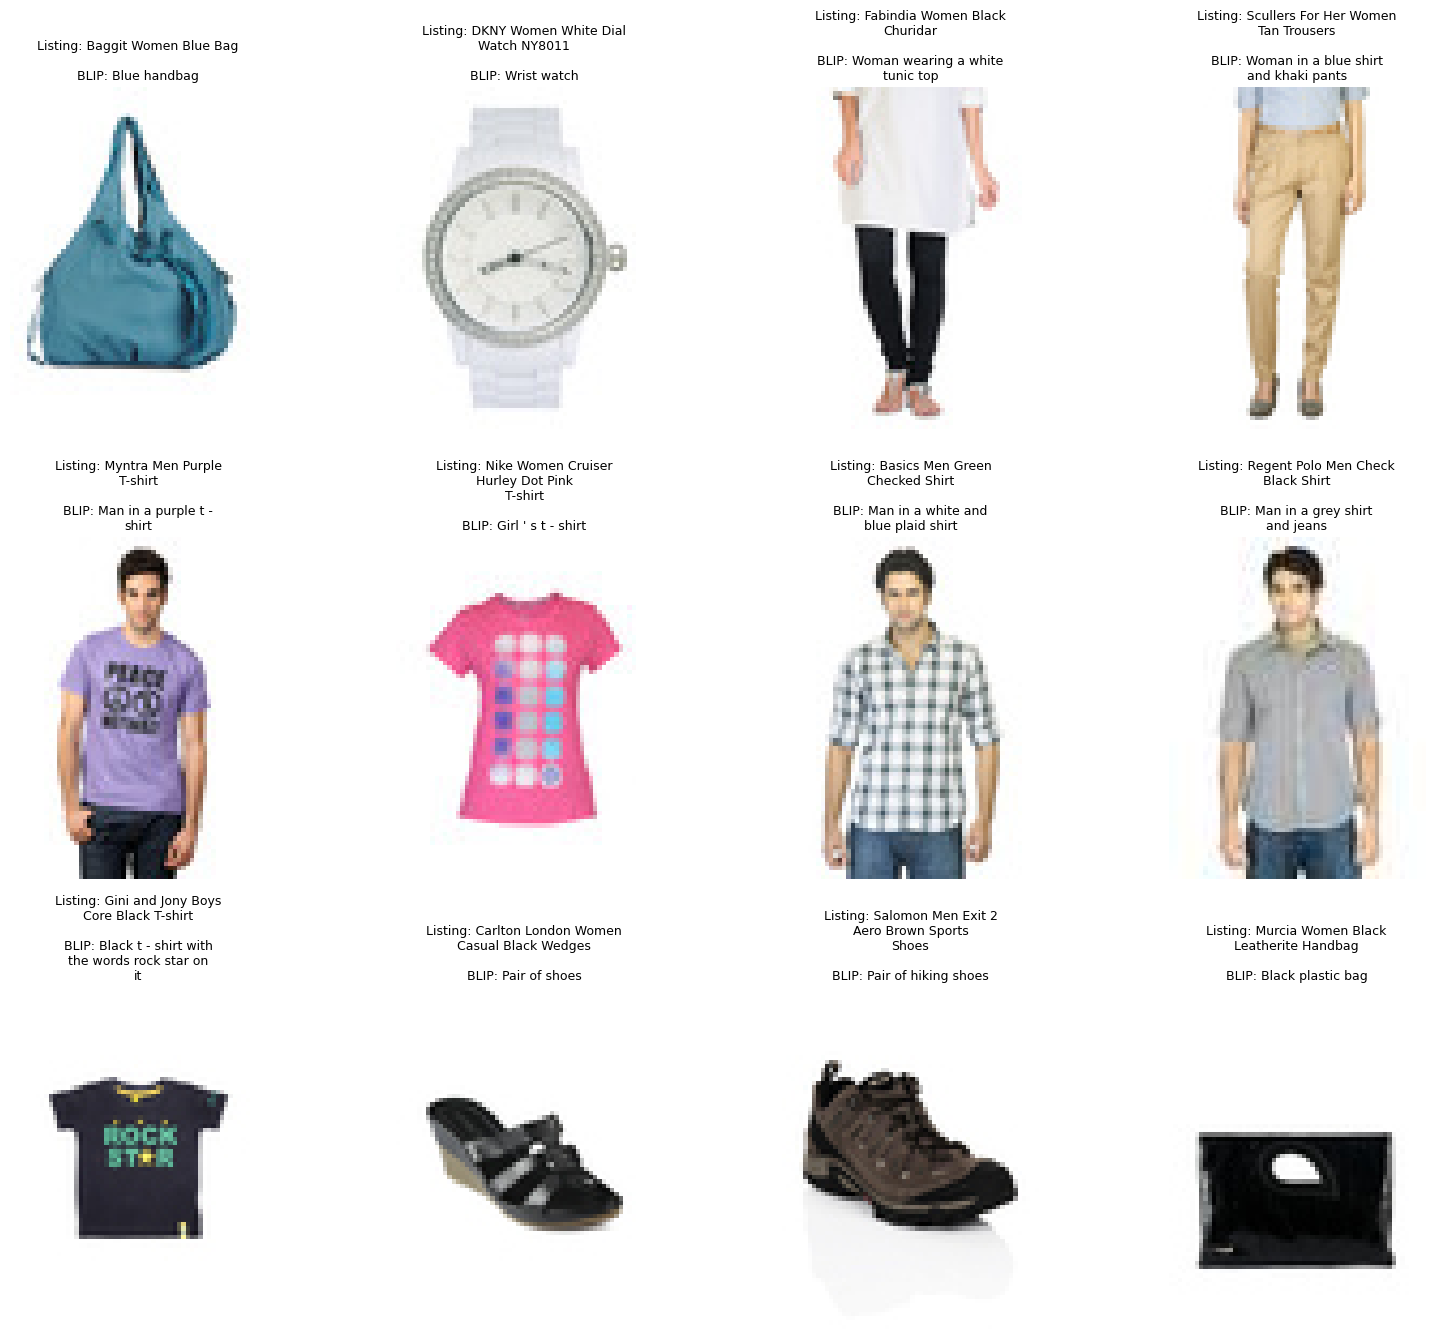

In [10]:
results = []
for row in sample:
    caption = generate_ecommerce_caption(row["image"])
    results.append({
        "id": row["id"],
        "image": row["image"],
        "listing_title": row["productDisplayName"],
        "generated_caption": caption,
        "category": row["articleType"],
    })

cols = 4
rows = (len(results) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4.5 * rows))
axes = axes.flatten()

for ax, r in zip(axes, results):
    ax.imshow(r["image"])
    ax.axis("off")
    title = f"Listing: {textwrap.fill(r['listing_title'], 22)}\n\nBLIP: {textwrap.fill(r['generated_caption'], 22)}"
    ax.set_title(title, fontsize=9)

for ax in axes[len(results):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 7. A rough sanity-check metric

Zero-shot captions won't (and shouldn't) match human listing titles word-for-word - different style, different goal. But measuring text overlap with ROUGE-L gives a cheap signal for *"is BLIP at least naming the right kind of product?"*, which is handy while iterating on prompts.

In [11]:
!pip install -q rouge_score

  Preparing metadata (setup.py) ... done


In [12]:
import evaluate

rouge = evaluate.load("rouge")
scores = rouge.compute(
    predictions=[r["generated_caption"] for r in results],
    references=[r["listing_title"] for r in results],
    use_aggregator=True,
)
print({k: round(v, 3) for k, v in scores.items()})

{'rouge1': np.float64(0.211), 'rouge2': np.float64(0.07), 'rougeL': np.float64(0.207), 'rougeLsum': np.float64(0.212)}


## 8. Try it on your own product photos

Upload one or more images from your computer and run the same pipeline on them.

Saving men shirt.jpg to men shirt.jpg


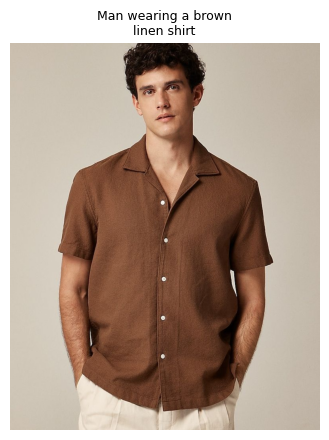

In [13]:
from google.colab import files

uploaded = files.upload()  # pick one or more image files

own_results = []
for filename, content in uploaded.items():
    image = Image.open(io.BytesIO(content)).convert("RGB")
    caption = generate_ecommerce_caption(image)
    own_results.append({"filename": filename, "image": image, "generated_caption": caption})

fig, axes = plt.subplots(1, len(own_results), figsize=(4 * len(own_results), 4.5))
axes = [axes] if len(own_results) == 1 else axes
for ax, r in zip(axes, own_results):
    ax.imshow(r["image"])
    ax.axis("off")
    ax.set_title(textwrap.fill(r["generated_caption"], 24), fontsize=9)
plt.tight_layout()
plt.show()

## 9. Save results

Export the generated captions (and key metadata) to a CSV - handy for a portfolio write-up or for loading into a spreadsheet.

In [14]:
df = pd.DataFrame([
    {
        "id": r["id"],
        "category": r["category"],
        "listing_title": r["listing_title"],
        "generated_caption": r["generated_caption"],
    }
    for r in results
])
df.to_csv("blip_ecommerce_captions.csv", index=False)
df

,id,category,listing_title,generated_caption
0,47396,Handbags,Baggit Women Blue Bag,Blue handbag
1,26335,Watches,DKNY Women White Dial Watch NY8011,Wrist watch
2,30811,Churidar,Fabindia Women Black Churidar,Woman wearing a white tunic top
3,27901,Trousers,Scullers For Her Women Tan Trousers,Woman in a blue shirt and khaki pants
4,34332,Tshirts,Myntra Men Purple T-shirt,Man in a purple t - shirt
5,28528,Tshirts,Nike Women Cruiser Hurley Dot Pink T-shirt,Girl ' s t - shirt
6,29821,Shirts,Basics Men Green Checked Shirt,Man in a white and blue plaid shirt
7,16789,Shirts,Regent Polo Men Check Black Shirt,Man in a grey shirt and jeans
8,39002,Tshirts,Gini and Jony Boys Core Black T-shirt,Black t - shirt with the words rock star on it
9,20760,Heels,Carlton London Women Casual Black Wedges,Pair of shoes
